# Image Realignment

This notebook realigns image files using matching `alignment.csv` files. Pairing is sequential: the first image path is paired with the first alignment CSV path, the second with the second, and so on.

The helper module reads image metadata with BioIO, reads image tiles with tifffile, aligns the full image extent, preserves available channels and Z planes, writes a full-resolution chunked Zarr internally, and can export pyramidal `.ome.zarr` and/or pyramidal `.ome.tiff` outputs. Origin/offset metadata is written to the outputs so the local aligned canvas can be placed back into the Xenium coordinate frame.

In [14]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# Keep this before importing zarr, anndata, scvi, cupy, scarches, or RAPIDS libraries.
os.environ.setdefault("CONDA_PREFIX", sys.prefix)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/opt/anaconda3/envs/scvi_mac'

# 1. Config
Set the input paths and runtime controls here. Leave `OUTPUT_DIR` as `outputs` unless you want the aligned files elsewhere

In [28]:
from pathlib import Path
import numpy as np

OME_TIFF = Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/20240627__192310__KAECH_AD_GBM_240627/output-XETG00224__0023902__APPPS1_infected_453f30__20240627__192344/morphology.ome.tif")

ALIGNMENT_CSV_PATHS = [
    Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/Post Xenium IF/APPPS1_infectedIF_alignment_files/matrix.csv"),
    Path("/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/MAIN LAB FOLDER (Ordering, lab meetings, protocols, IACUC)/Spatial transcriptomics datasets/Post Xenium IF/Morphology_alignment_files_APP_Mock/matrix.csv"),
]

OUTPUT_DIR = '/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/07_find_plaques'
OUTPUT_FORMATS = (".ome.tiff", ".ome.zarr")

# .ome.zarr and .ome.tiff have metadata ("translation" and "Plane PositionX"/"Plane PositionY", respectively) that should automatically sync to Xenium coordinates
# .zarr can be faster/more lightweight for read/write/analysis, but doesn't come with standardized metadata
## plain .zarr requires analysis code to explicitly read and apply "origin_global_xy_px" or "origin_um_xy", where pixel_size_x_um == pixel_size_y_um == 0.2125

OVERWRITE = False
VALIDATE_METADATA = True

BACKEND = False
VALIDATE_BACKEND = True

BACKEND = "cpu"
EXECUTION_MODE = "serial"  # "serial" or "parallel"
WORKERS_CPU = 4
WORKERS_GPU = 1
GPU_DEVICE_IDS = [0, 1, 2, 3]  # list of GPU device IDs to use for parallel execution
GPU_JOBS_PER_DEVICE = 1
INNER_NUM_THREADS = 1  # number of threads to use for each job (if using parallel execution)

#Image/channel/Z and dtype controls. Use None to align all channels/Z planes.
CHANNEL_INDICES = None  # list of channel indices to align (0-based). Use None to align all channels
Z_INDICES = None  # list of Z indices to align (0-based). Use None to align all Z planes
CPU_READ_DTYPE = np.uint16
ALIGN_DTYPE = np.uint16
GPU_SOURCE_DTYPE = "float32"

# Output coordinate pixel size. For Xenium Explorer alignments, this should 
# match the Xenium morphology image pixel size, not the source image pixel size
TARGET_PIXEL_SIZE_X_UM = 0.2125
TARGET_PIXEL_SIZE_Y_UM = 0.2125

# Tiling/chunking control. 
ALIGN_TILE_Y = 2048
ALIGN_TILE_X = 2048
WRITE_CHUNKS = (2048, 2048)
ALIGN_RESAMPLER = "affine"

SOURCE_WINDOW_PAD_PX = 2

# WRITE CONTROLS 
OME_ZARR_FORMAT = 3
OME_TIFF_COMPRESSION = "zlib"  # "zlib", "jpeg", "none"
OME_ZARR_COMPRESSION = "zlib"  # "zlib", "jpeg", "none"
OME_TILE_SIZE = 1024
PYRAMID_SCALE = 2

# Downsampled before/after QC controls. 
QC_MAX_IMAGES = 6
QC_MAX_SIZE_PX = 1024
QC_SOURCE_CHANNEL = None
QC_ALIGNED_CHANNEL = 0

RAM_START_PCT = 85.0
RAM_RESUME_PCT = 75.0
RAM_POLL_S = 10.0
WORKER_STAGGER_S = 0.0



# 2. Load Helper

In [16]:
import importlib
import time
import pandas as pd
from IPython.display import display, HTML

import image_realignment as ir
ir = importlib.reload(ir)

backend_info = ir.resolve_backend(BACKEND)
print("Loaded", ir.__file__)

print(
    f"Backend: requested={backend_info['requested_backend']}, "
    f"effective={backend_info['effective_backend']}, "
    f"platform={backend_info['host_platform']}"
)

Loaded /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/SCRIPTS/image_realignment.py
Backend: requested=cpu, effective=cpu, platform=osx-arm64


# 3. Build Plan
This reads image metadata with BioIO, validates the sequential pairs, preserves available channel names, and checks whether matching outputs already exist

In [24]:
plan_df, plan_lines = ir.build_realignment_plan(
    image_paths=OME_TIFF,
    alignment_csv_paths=ALIGNMENT_CSV_PATHS,
    output_dir=OUTPUT_DIR,
    output_formats=(".ome.tiff",),
    overwrite=True,
    channel_indices=[0],
    z_indices=[3],  # or your best Z plane
)

display(plan_df)
print("\n".join(plan_lines))

plan_df, plan_lines = ir.build_realignment_plan(
    image_paths=OME_TIFF,
    alignment_csv_paths=ALIGNMENT_CSV_PATHS,
    output_dir=OUTPUT_DIR,
    output_formats=OUTPUT_FORMATS,
    overwrite=OVERWRITE,
    validate_metadata=VALIDATE_METADATA,
    backend=BACKEND,
    align_dtype=ALIGN_DTYPE,
    cpu_read_dtype=CPU_READ_DTYPE,
    gpu_source_dtype=GPU_SOURCE_DTYPE,
    align_tile_y=ALIGN_TILE_Y,
    align_tile_x=ALIGN_TILE_X,
    write_chunks=WRITE_CHUNKS,
    align_resampler=ALIGN_RESAMPLER,
    channel_indices=CHANNEL_INDICES,
    z_indices=Z_INDICES,
    source_window_pad_px=SOURCE_WINDOW_PAD_PX,
    ome_zarr_format=OME_ZARR_FORMAT,
    ome_tiff_compression=OME_TIFF_COMPRESSION,
    ome_zarr_compression=OME_ZARR_COMPRESSION,
    ome_tile_size=OME_TILE_SIZE,
    pyramid_scale=PYRAMID_SCALE,
    target_pixel_size_x_um=TARGET_PIXEL_SIZE_X_UM,
    target_pixel_size_y_um=TARGET_PIXEL_SIZE_Y_UM,
)

display_cols = [
    "pair_index", "image_id", "needs_run", "plan_reason",
    "backend", "effective_backend", "host_platform",
    "channel_indices", "selected_channel_names",
    "z_count", "z_indices",
    "source_pixel_size_x_um", "source_pixel_size_y_um",
    "pixel_size_x_um", "pixel_size_y_um",
    "output_pixel_size_source",
    "image_path", "alignment_csv",
    "out_zarr", "out_ome_zarr", "out_ome_tiff",
]

print("\n".join(plan_lines) if plan_lines else "No input pairs configured.")
display(plan_df[[c for c in display_cols if c in plan_df.columns]])



,pair_index,image_id,image_path,alignment_csv,alignment_matrix,backend,implementation_backend,effective_backend,host_platform,source_shape_yx,...,channel_names,selected_channel_names,output_formats,output_paths,out_zarr,out_ome_zarr,out_ome_tiff,alignment_expected_inputs,needs_run,plan_reason
0,1,morphology_APPPS1_infectedIF_alignment_files,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...,"[[0.013467998, 3.0520709, -480.26843], [-3.052...",cpu,cpu,cpu,osx-arm64,"[30724, 39875]",...,[DAPI],[DAPI],"(.ome.tiff,)",{'.ome.tiff': '/Users/valishashah/Library/Clou...,None,None,/Users/valishashah/Library/CloudStorage/Box-Bo...,"{'pipeline_version': 'image_realignment_v4', '...",True,OVERWRITE=True
1,2,morphology_Morphology_alignment_files_APP_Mock,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...,"[[1.0002177, 8.3302075e-05, -4.451959], [-8.33...",cpu,cpu,cpu,osx-arm64,"[30724, 39875]",...,[DAPI],[DAPI],"(.ome.tiff,)",{'.ome.tiff': '/Users/valishashah/Library/Clou...,None,None,/Users/valishashah/Library/CloudStorage/Box-Bo...,"{'pipeline_version': 'image_realignment_v4', '...",True,OVERWRITE=True


morphology_APPPS1_infectedIF_alignment_files: OVERWRITE=True
morphology_Morphology_alignment_files_APP_Mock: OVERWRITE=True
morphology_APPPS1_infectedIF_alignment_files: missing outputs: .ome.tiff, .ome.zarr
morphology_Morphology_alignment_files_APP_Mock: missing outputs: .ome.tiff, .ome.zarr


,pair_index,image_id,needs_run,plan_reason,backend,effective_backend,host_platform,channel_indices,selected_channel_names,z_count,...,source_pixel_size_x_um,source_pixel_size_y_um,pixel_size_x_um,pixel_size_y_um,output_pixel_size_source,image_path,alignment_csv,out_zarr,out_ome_zarr,out_ome_tiff
0,1,morphology_APPPS1_infectedIF_alignment_files,True,"missing outputs: .ome.tiff, .ome.zarr",cpu,cpu,osx-arm64,"(0,)",[DAPI],13,...,0.2125,0.2125,0.2125,0.2125,target_pixel_size_config,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...,None,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...
1,2,morphology_Morphology_alignment_files_APP_Mock,True,"missing outputs: .ome.tiff, .ome.zarr",cpu,cpu,osx-arm64,"(0,)",[DAPI],13,...,0.2125,0.2125,0.2125,0.2125,target_pixel_size_config,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...,None,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...


# 4. Run Realignment

In [29]:
def make_progress_display(label):
    handle = display(HTML(f"<b>0 out of 0 images {label}</b>"), display_id=True)
    def update(status):
        parts = [f"<b>{status.get('n_done', 0)} out of {status.get('n_total', 0)} images {label}</b>"]
        if status.get("current_image_id") is not None:
            parts.append(f"Working on: {status['current_image_id']}")
        parts.append(f"failed: {status.get('n_failed', 0)}")
        if status.get("ram_percent") is not None:
            parts.append(f"RAM: {status['ram_percent']:.1f}% used, {status['ram_available_gb']:.1f} GB available")
        handle.update(HTML("<br>".join(parts)))
    return handle, update

run_t0 = time.perf_counter()
status_handle, progress = make_progress_display("realigned")

realignment_run = ir.run_realignment_batch(
    plan_df,
    backend=BACKEND,
    execution_mode=EXECUTION_MODE,
    workers_cpu=WORKERS_CPU,
    workers_gpu=WORKERS_GPU,
    gpu_device_ids=GPU_DEVICE_IDS,
    gpu_jobs_per_device=GPU_JOBS_PER_DEVICE,
    run_only_needed=True,
    progress_callback=progress,
    ram_start_pct=RAM_START_PCT,
    ram_resume_pct=RAM_RESUME_PCT,
    ram_poll_s=RAM_POLL_S,
    worker_stagger_s=WORKER_STAGGER_S,
    overwrite=OVERWRITE,
    align_dtype=ALIGN_DTYPE,
    cpu_read_dtype=CPU_READ_DTYPE,
    gpu_source_dtype=GPU_SOURCE_DTYPE,
    align_tile_y=ALIGN_TILE_Y,
    align_tile_x=ALIGN_TILE_X,
    write_chunks=WRITE_CHUNKS,
    align_resampler=ALIGN_RESAMPLER,
    source_window_pad_px=SOURCE_WINDOW_PAD_PX,
    output_formats=OUTPUT_FORMATS,
    output_dir=OUTPUT_DIR,
    ome_zarr_format=OME_ZARR_FORMAT,
    ome_tiff_compression=OME_TIFF_COMPRESSION,
    ome_zarr_compression=OME_ZARR_COMPRESSION,
    ome_tile_size=OME_TILE_SIZE,
    pyramid_scale=PYRAMID_SCALE,
    inner_num_threads=INNER_NUM_THREADS,
)

elapsed = time.perf_counter() - run_t0
status_handle.update(HTML(
    f"<b>Finished: {realignment_run['n_done']} out of {realignment_run['n_total']} images realigned</b><br>"
    f"failed: {realignment_run['n_failed']}<br>elapsed: {elapsed/60:.1f} min"
))

# Results

In [30]:
profile_df = realignment_run["profile_df"]
display(ir.summarize_realignment_results(profile_df))

if len(profile_df) and "output_paths" in profile_df.columns:
    display(profile_df[["image_id", "output_paths", "error"]])

if realignment_run.get("n_total", 0) > 0 and realignment_run.get("n_failed", 0) == 0:
    print(ir._completion_message())

,ok,image_id,backend,implementation_backend,effective_backend,host_platform,device_id,aligned_axes,aligned_shape,aligned_shape_cyx,aligned_shape_yx,n_tiles,n_tiles_skipped,t_total_s,error
0,True,morphology_APPPS1_infectedIF_alignment_files,cpu,cpu,cpu,osx-arm64,None,"[c, z, y, x]","(1, 13, 122116, 94310)","(1, 13, 122116, 94310)","(122116, 94310)",36049,611,35494.178363,None
1,True,morphology_Morphology_alignment_files_APP_Mock,cpu,cpu,cpu,osx-arm64,None,"[c, z, y, x]","(1, 13, 30735, 39887)","(1, 13, 30735, 39887)","(30735, 39887)",4160,0,1160.725811,None


,image_id,output_paths,error
0,morphology_APPPS1_infectedIF_alignment_files,{'.ome.zarr': '/Users/valishashah/Library/Clou...,None
1,morphology_Morphology_alignment_files_APP_Mock,{'.ome.zarr': '/Users/valishashah/Library/Clou...,None


I hope you have a wonderful day, Valisha! 😊


# 6. Downsampled QC
This displays a few downsampled source/aligned parids and prints the output paths plus stored origin when available

morphology_APPPS1_infectedIF_alignment_files: QC output=/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/07_find_plaques/morphology_APPPS1_infectedIF_alignment_files_aligned.ome.zarr
morphology_APPPS1_infectedIF_alignment_files: origin_global_xy_px=[-481.0, -91934.0]
morphology_Morphology_alignment_files_APP_Mock: QC output=/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/07_find_plaques/morphology_Morphology_alignment_files_APP_Mock_aligned.ome.zarr
morphology_Morphology_alignment_files_APP_Mock: origin_global_xy_px=[-5.0, -6.0]


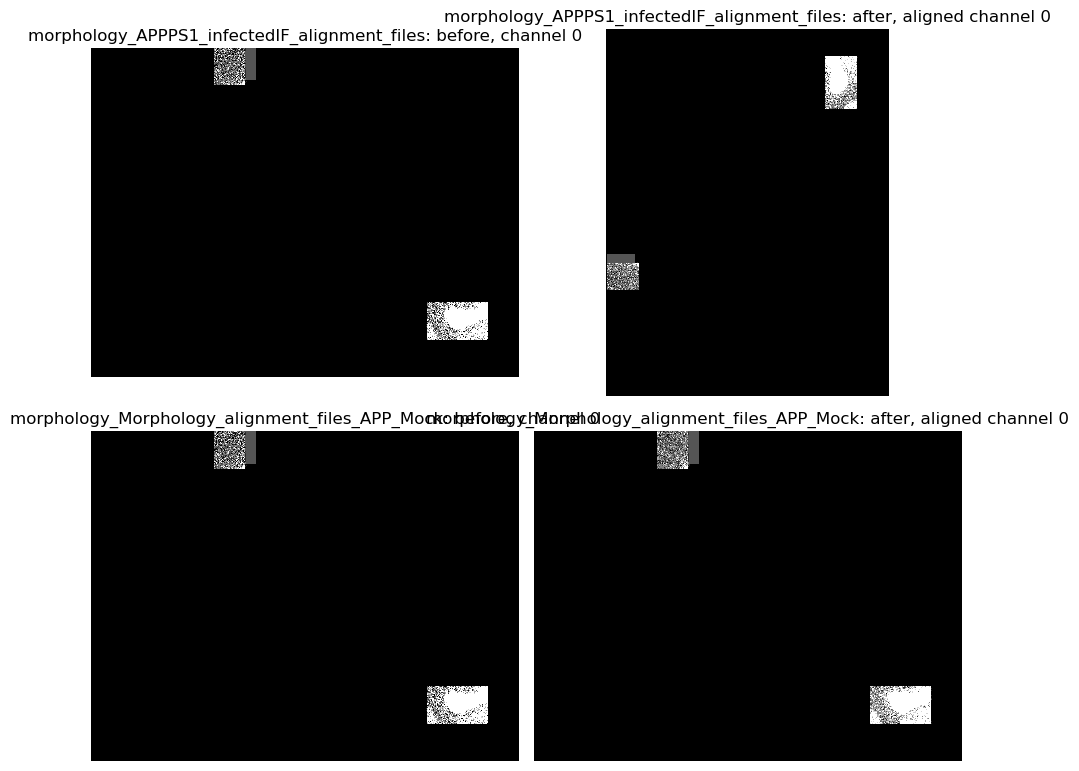

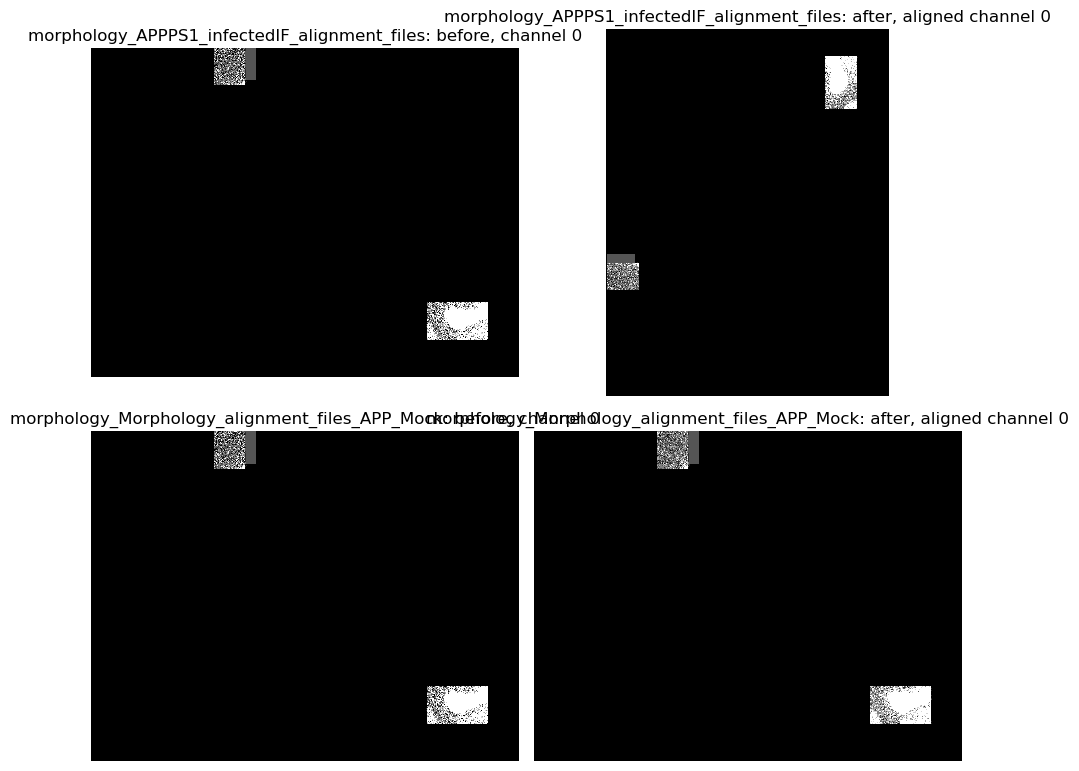

In [31]:
ir.plot_realignment_qc(
    plan_df,
    results_df=profile_df,
    max_images=QC_MAX_IMAGES,
    max_size_px=QC_MAX_SIZE_PX,
    source_channel=QC_SOURCE_CHANNEL,
    aligned_channel=QC_ALIGNED_CHANNEL,
)